In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

NOTEBOOK_DIR = Path.cwd().resolve()
NOTEBOOKS_DIR = NOTEBOOK_DIR if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR.parent
ROOT = NOTEBOOKS_DIR.parent

sys.path.insert(0, str(NOTEBOOKS_DIR))

from plot_style import PLOTNINE_COLORS, finalize_figure, prepare_figure, rc_context, style_2d_axes

CKPT = ROOT / "data" / "processed" / "checkpoints"
FIG_DIR = ROOT / "figures" / "training"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TICK_FONTSIZE = 16
LABEL_FONTSIZE = 16
TITLE_FONTSIZE = 16
LEGEND_FONTSIZE = 14

THEME_RC = {
    "xtick.labelsize": TICK_FONTSIZE,
    "ytick.labelsize": TICK_FONTSIZE,
    "axes.labelsize": LABEL_FONTSIZE,
    "axes.titlesize": TITLE_FONTSIZE,
    "legend.fontsize": LEGEND_FONTSIZE,
}

unet_epoch = pd.read_csv(CKPT / "training_epoch_history.csv")
trans_epoch = pd.read_csv(CKPT / "trans_training_epoch_history.csv")

print(f"UNet:  {len(unet_epoch)} epochs")
print(f"Trans: {len(trans_epoch)} epochs")
print(f"Saving PDFs to: {FIG_DIR}")

ModuleNotFoundError: No module named 'plot_style'

In [ ]:
EPOCH_COMPONENTS = [
    ("loss_eps_mean", "val_loss_eps", r"$\epsilon$-MSE"),
    ("loss_smooth_mean", "val_loss_smooth", "Smoothness"),
    ("loss_arb_mean", "val_loss_arb", "Arbitrage penalty"),
]

TRAIN_COLOR = PLOTNINE_COLORS[0]  # blue
VAL_COLOR = PLOTNINE_COLORS[1]    # red
TRAIN_LINESTYLE = "-"
VAL_LINESTYLE = "--"
TRAIN_MARKER = "o"
VAL_MARKER = "s"

# In-axes legend placement for component plots.
LEGEND_LOC = "lower right"
LEGEND_BBOX = (1, 0.16)  # increase y to move legend up
LEGEND_FRAME_ALPHA = 0.72

COMPONENT_TITLES = {
    "unet": "UNet Diffusion Model: Epoch Loss Components",
    "transformer": "Transformer Diffusion Model: Epoch Loss Components",
}

OVERALL_TITLES = {
    "unet": "UNet Diffusion Model: Overall Epoch Loss",
    "transformer": "Transformer Diffusion Model: Overall Epoch Loss",
}


def _marker_stride(n_points: int, target: int = 12) -> int:
    return max(1, n_points // target)


def _style_log_training_axes(ax: plt.Axes) -> None:
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (log scale)")
    style_2d_axes(ax, theme="plotnine")
    ax.set_axisbelow(True)


def _style_component_legend(ax: plt.Axes) -> None:
    ax.legend(
        loc=LEGEND_LOC,
        bbox_to_anchor=LEGEND_BBOX,
        frameon=True,
        framealpha=LEGEND_FRAME_ALPHA,
        facecolor="white",
        edgecolor="#CCCCCC",
        ncol=2,
        fontsize=LEGEND_FONTSIZE,
        handlelength=1.6,
        columnspacing=0.8,
        labelspacing=0.3,
        borderpad=0.3,
        markerscale=0.75,
    )


def _save_publication_figure(fig: plt.Figure, path: Path) -> None:
    prepare_figure(fig)
    fig.savefig(path, format="pdf", bbox_inches="tight", pad_inches=0.03)


def plot_epoch_loss_components(
    epoch_df: pd.DataFrame,
    *,
    model_slug: str,
    model_name: str,
) -> Path:
    """Publication panel: all epoch loss components in one plot."""
    with rc_context("plotnine", **THEME_RC):
        fig, ax = plt.subplots(figsize=(7.2, 4.5))
        epochs = epoch_df["epoch"].to_numpy()
        mark_every = _marker_stride(len(epochs))

        for i, (train_col, val_col, label) in enumerate(EPOCH_COMPONENTS):
            color = PLOTNINE_COLORS[i]
            ax.plot(
                epochs,
                epoch_df[train_col],
                color=color,
                linestyle=TRAIN_LINESTYLE,
                marker=TRAIN_MARKER,
                markevery=mark_every,
                markersize=4.2,
                lw=1.8,
                label=f"Train: {label}",
                zorder=3,
            )
            if val_col in epoch_df.columns and epoch_df[val_col].notna().any():
                ax.plot(
                    epochs,
                    epoch_df[val_col],
                    color=color,
                    linestyle=VAL_LINESTYLE,
                    marker=VAL_MARKER,
                    markevery=mark_every,
                    markersize=3.8,
                    lw=1.6,
                    label=f"Val: {label}",
                    zorder=3,
                )

        _style_log_training_axes(ax)
        ax.set_title(
            COMPONENT_TITLES.get(model_slug, f"{model_name}: Epoch Loss Components"),
            fontsize=TITLE_FONTSIZE,
            pad=10,
        )
        _style_component_legend(ax)

        out_path = FIG_DIR / f"{model_slug}_epoch_loss_components.pdf"
        _save_publication_figure(fig, out_path)
        plt.show()
        plt.close(fig)
        return out_path


def plot_epoch_overall_loss(
    epoch_df: pd.DataFrame,
    *,
    model_slug: str,
    model_name: str,
) -> Path:
    """Publication panel: overall train vs validation epoch loss."""
    with rc_context("plotnine", **THEME_RC):
        fig, ax = plt.subplots(figsize=(7.2, 4.5))
        epochs = epoch_df["epoch"].to_numpy()
        mark_every = _marker_stride(len(epochs))

        ax.plot(
            epochs,
            epoch_df["loss_mean"],
            color=TRAIN_COLOR,
            linestyle=TRAIN_LINESTYLE,
            marker=TRAIN_MARKER,
            markevery=mark_every,
            markersize=4.2,
            lw=1.8,
            label="Train loss",
            zorder=3,
        )
        if "val_loss" in epoch_df.columns and epoch_df["val_loss"].notna().any():
            ax.plot(
                epochs,
                epoch_df["val_loss"],
                color=VAL_COLOR,
                linestyle=VAL_LINESTYLE,
                marker=VAL_MARKER,
                markevery=mark_every,
                markersize=3.8,
                lw=1.6,
                label="Validation loss",
                zorder=3,
            )

        _style_log_training_axes(ax)
        ax.set_title(
            OVERALL_TITLES.get(model_slug, f"{model_name}: Overall Epoch Loss"),
            fontsize=TITLE_FONTSIZE,
            pad=10,
        )
        ax.legend(
            loc="upper right",
            frameon=True,
            framealpha=LEGEND_FRAME_ALPHA,
            facecolor="white",
            edgecolor="#CCCCCC",
            fontsize=LEGEND_FONTSIZE,
            handlelength=2.0,
            borderpad=0.35,
            markerscale=0.8,
        )
        finalize_figure(fig, rect=(0, 0, 1, 1))

        out_path = FIG_DIR / f"{model_slug}_epoch_overall_loss.pdf"
        _save_publication_figure(fig, out_path)
        plt.show()
        plt.close(fig)
        return out_path

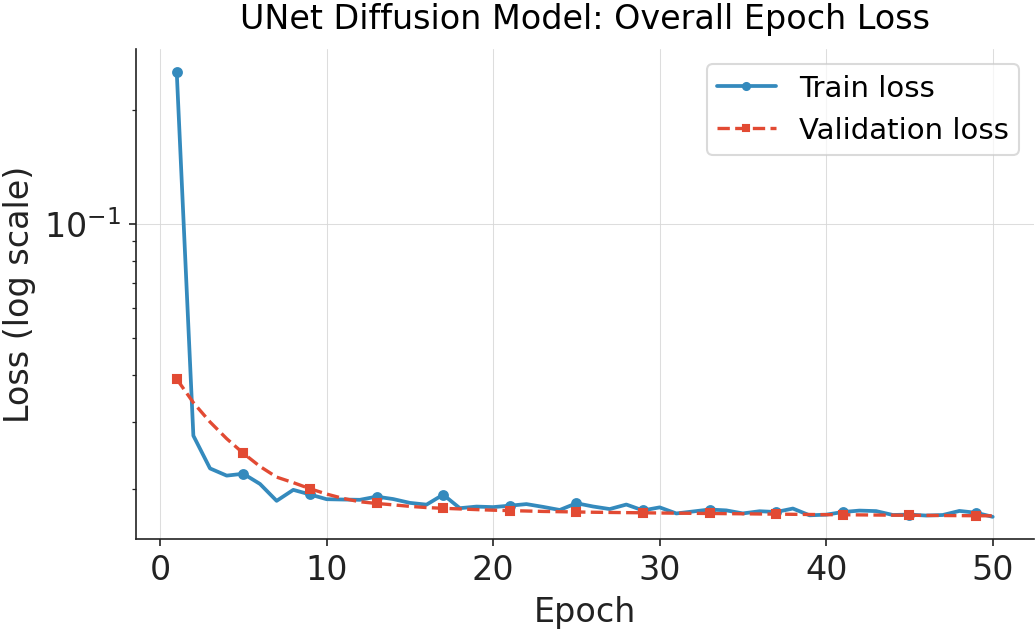

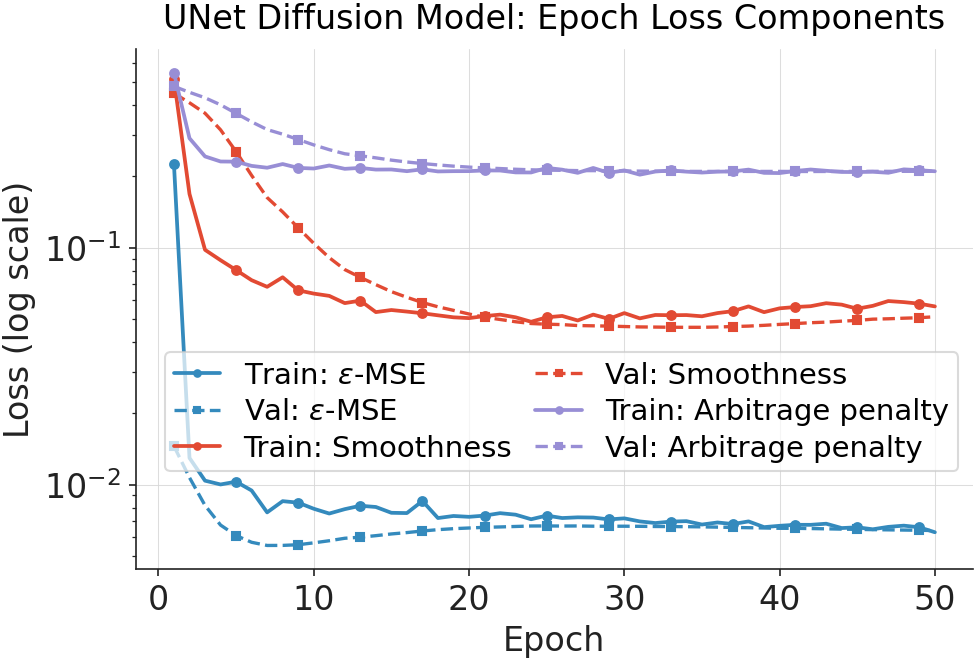

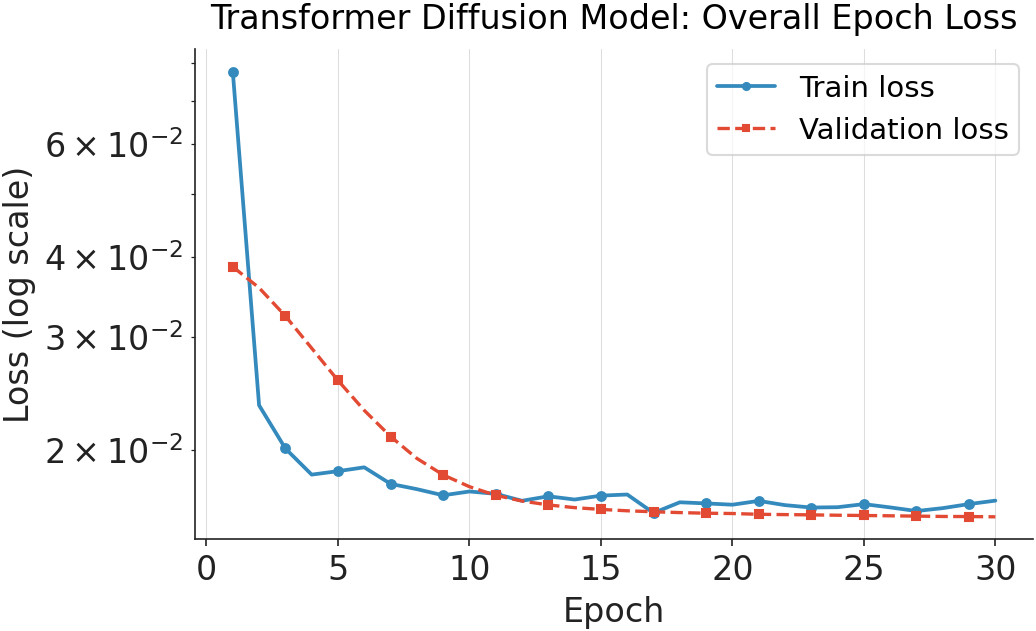

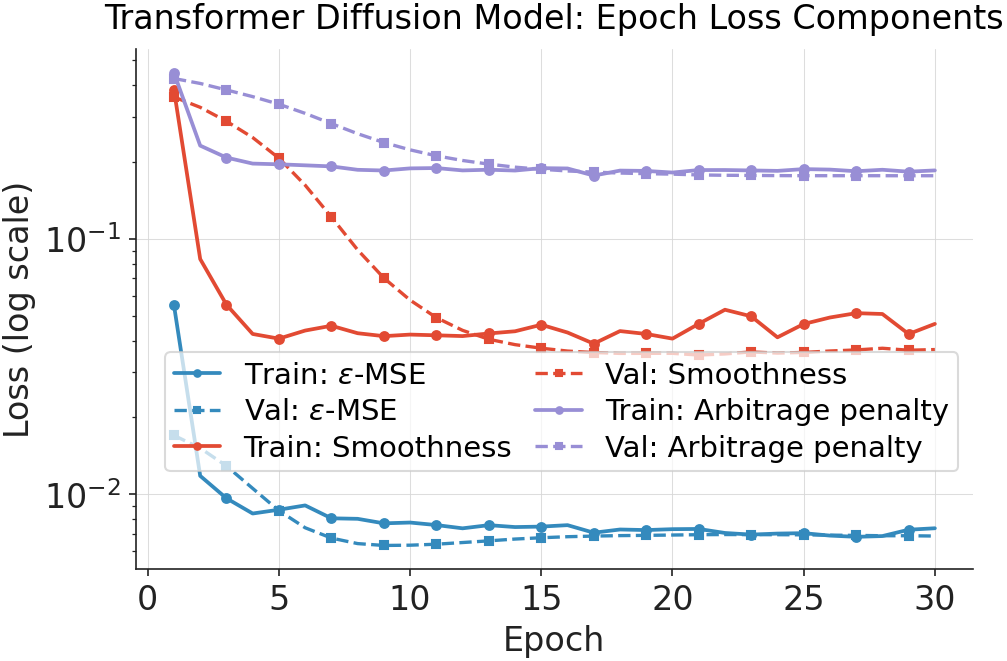

In [ ]:
MODELS = [
    ("unet", "UNet", unet_epoch),
    ("transformer", "Transformer", trans_epoch),
]

saved_paths: list[Path] = []

for model_slug, model_name, epoch_df in MODELS:
    saved_paths.append(
        plot_epoch_overall_loss(epoch_df, model_slug=model_slug, model_name=model_name)
    )
    saved_paths.append(
        plot_epoch_loss_components(epoch_df, model_slug=model_slug, model_name=model_name)
    )